# Experiment No. 06
## Logistic Regression, Thresholds and Classification Metrics

## Aim

To implement a Logistic Regression classifier, obtain predicted probabilities, study the effect of different classification thresholds on precision and recall, analyze confusion matrices, and use ROC and Precision-Recall curves to select an appropriate classification threshold.

## Objectives

After completing this experiment, students will be able to:

1. Understand the concept of Logistic Regression for binary classification.
2. Understand the sigmoid function and predicted probabilities.
3. Train a Logistic Regression classifier using a dataset.
4. Obtain class probabilities using `predict_proba()`.
5. Understand the concept of a classification threshold.
6. Study how changing the threshold affects precision and recall.
7. Construct and interpret a confusion matrix.
8. Calculate classification metrics such as precision and recall.
9. Plot and interpret ROC and Precision-Recall curves.
10. Select a suitable classification threshold based on the real-world cost of false positives and false negatives.

## Theory

### Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. It predicts the probability that an observation belongs to the positive class.

The model first calculates a linear combination of the input features:

$$
z = b_0 + b_1x_1 + b_2x_2 + \cdots + b_nx_n
$$

This value is passed through the sigmoid function:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The sigmoid function converts the output into a value between 0 and 1, which can be interpreted as the probability of belonging to the positive class.

### Classification Threshold

The predicted probability is converted into a class using a threshold.

For example, with a threshold of 0.5:

- Probability >= 0.5 → Class 1
- Probability < 0.5 → Class 0

The threshold can be changed depending on the requirements of the application.

### Precision

Precision measures how many of the observations predicted as positive are actually positive.

$$
Precision = \frac{TP}{TP + FP}
$$

### Recall

Recall measures how many of the actual positive observations were correctly identified.

$$
Recall = \frac{TP}{TP + FN}
$$

### Confusion Matrix

A confusion matrix contains four quantities:

- **TP (True Positive):** Correctly predicted positive
- **TN (True Negative):** Correctly predicted negative
- **FP (False Positive):** Negative sample incorrectly predicted as positive
- **FN (False Negative):** Positive sample incorrectly predicted as negative

### ROC Curve

The ROC (Receiver Operating Characteristic) curve shows the relationship between True Positive Rate and False Positive Rate at different classification thresholds.

### Precision-Recall Curve

The Precision-Recall curve shows the relationship between precision and recall at different thresholds. It is particularly useful when dealing with imbalanced datasets.

## Pseudo Algorithm

1. Start.
2. Load the classification dataset.
3. Separate features X and target y.
4. Split the dataset into training and testing sets.
5. Train a Logistic Regression classifier.
6. Obtain predicted probabilities using `predict_proba()`.
7. Store the positive-class probability.
8. Select different thresholds such as 0.1, 0.3, 0.5, 0.7 and 0.9.
9. Convert probabilities into class predictions using each threshold.
10. Calculate the confusion matrix for each threshold.
11. Calculate precision and recall.
12. Compare the metrics across thresholds.
13. Plot the ROC curve.
14. Plot the Precision-Recall curve.
15. Check the class distribution.
16. Identify whether the dataset is imbalanced.
17. Select a real-world application where false positives and false negatives have different costs.
18. Select an appropriate threshold based on the application.
19. Justify the selected threshold.
20. Stop.

## Tools / Software Required

### Hardware
- Computer/Laptop
- Minimum 4 GB RAM

### Software
- Python 3.x
- Jupyter Notebook or Google Colab
- Anaconda (optional)

### Python Libraries
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- Seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    classification_report
)

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Dataset Shape:", X.shape)

print("\nTarget Classes:")
print(data.target_names)

X.head()

Dataset Shape: (569, 30)

Target Classes:
['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
print("Number of Samples:", X.shape[0])
print("Number of Features:", X.shape[1])

print("\nMissing Values:")
print(X.isnull().sum().sum())

print("\nClass Distribution:")
print(y.value_counts())

Number of Samples: 569
Number of Features: 30

Missing Values:
0

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


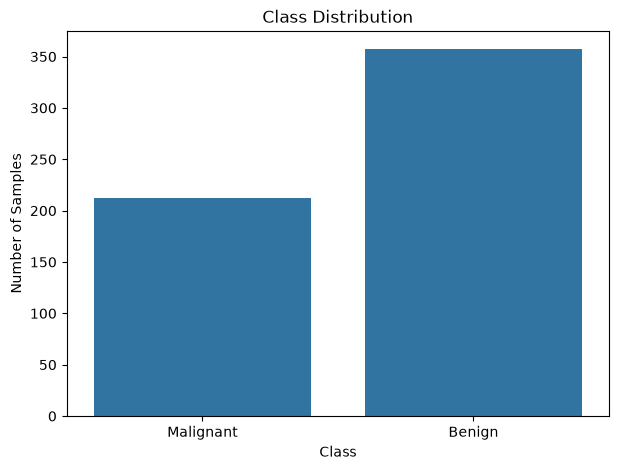

In [5]:
plt.figure(figsize=(7, 5))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 455
Testing Samples: 114


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [8]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [9]:
y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 Predicted Probabilities:")
print(y_prob[:10])

print("\nFirst 10 Predicted Classes:")
print(y_pred[:10])

First 10 Predicted Probabilities:
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11]

First 10 Predicted Classes:
[0 1 0 1 0 1 1 0 0 0]


In [10]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861


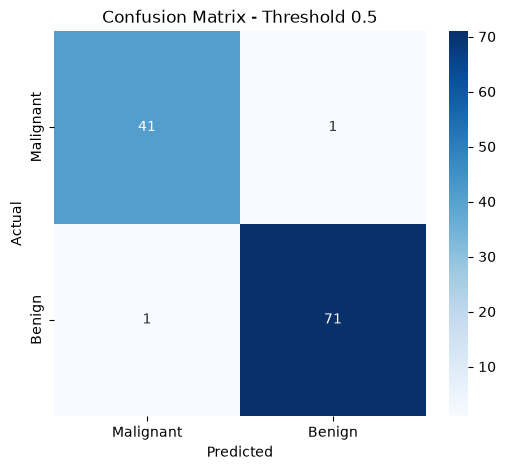

Confusion Matrix:
[[41  1]
 [ 1 71]]


In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Confusion Matrix - Threshold 0.5")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print("Confusion Matrix:")
print(cm)

In [12]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

results = []

for threshold in thresholds:

    y_threshold_pred = (
        y_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_test,
        y_threshold_pred
    )

    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(
        y_test,
        y_threshold_pred
    )

    precision = precision_score(
        y_test,
        y_threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_threshold_pred,
        zero_division=0
    )

    results.append([
        threshold,
        tn,
        fp,
        fn,
        tp,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "TN",
        "FP",
        "FN",
        "TP",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df.round(4)

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Recall,F1 Score
0,0.1,37,5,0,72,0.9561,0.9351,1.0000,0.9664
1,0.3,40,2,0,72,0.9825,0.9730,1.0000,0.9863
2,0.5,41,1,1,71,0.9825,0.9861,0.9861,0.9861
3,0.7,41,1,5,67,0.9474,0.9853,0.9306,0.9571
4,0.9,41,1,11,61,0.8947,0.9839,0.8472,0.9104


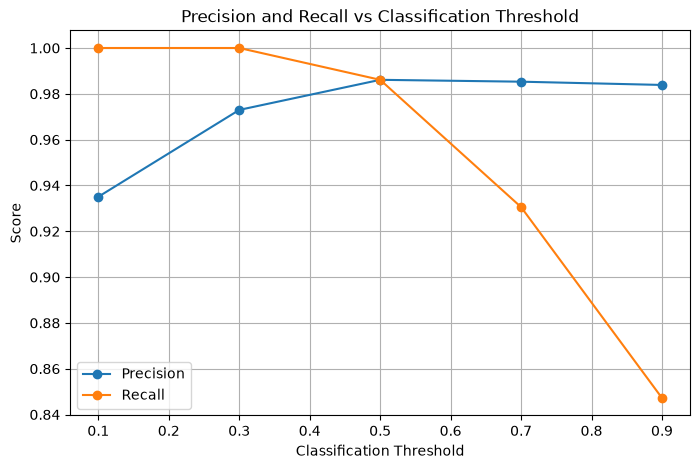

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Threshold"],
    results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    results_df["Threshold"],
    results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Precision and Recall vs Classification Threshold"
)

plt.legend()
plt.grid(True)

plt.show()

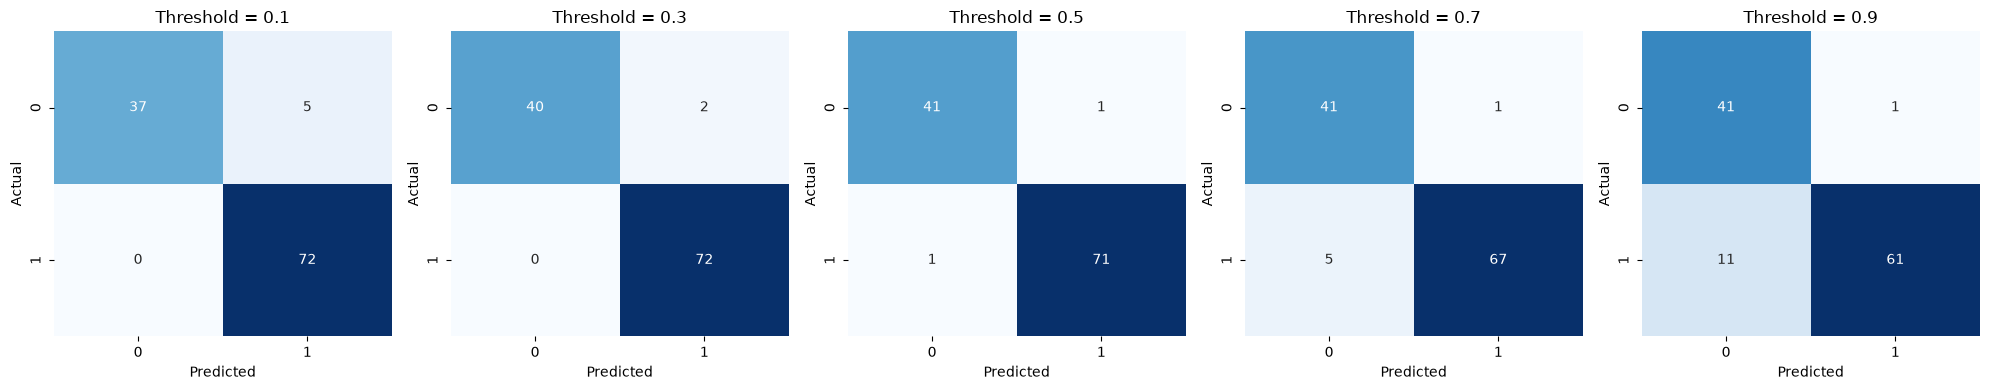

In [14]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 4)
)

for ax, threshold in zip(
    axes,
    thresholds
):

    y_threshold_pred = (
        y_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_test,
        y_threshold_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["0", "1"],
        yticklabels=["0", "1"]
    )

    ax.set_title(
        f"Threshold = {threshold}"
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()

plt.show()

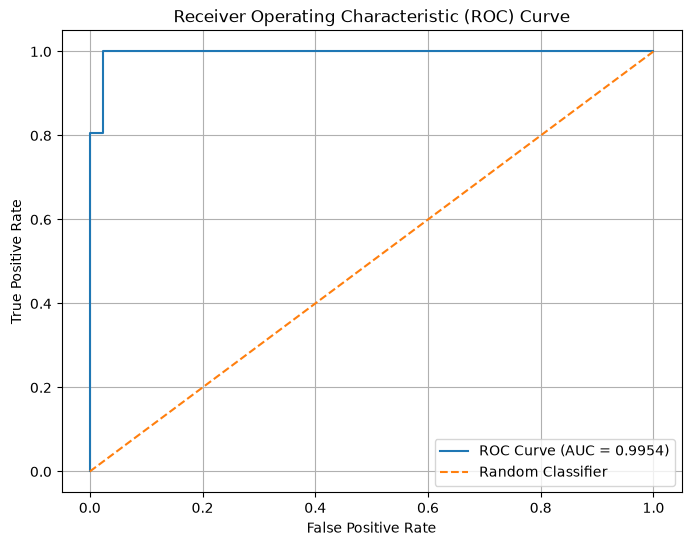

ROC-AUC Score: 0.9954


In [15]:
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Receiver Operating Characteristic (ROC) Curve"
)

plt.legend()
plt.grid(True)

plt.show()

print(
    "ROC-AUC Score:",
    round(roc_auc, 4)
)

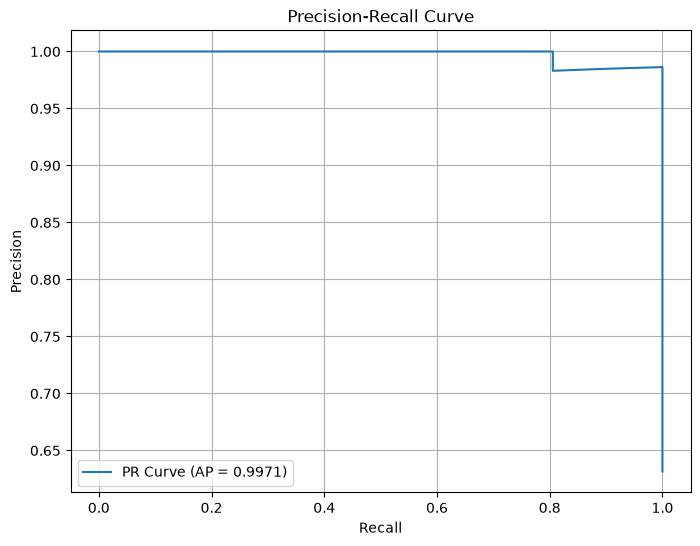

Average Precision Score: 0.9971


In [16]:
precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_prob
    )
)

average_precision = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"PR Curve (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve"
)

plt.legend()
plt.grid(True)

plt.show()

print(
    "Average Precision Score:",
    round(average_precision, 4)
)

In [17]:
best_f1_row = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Threshold with Highest F1 Score:")
print(
    "Threshold:",
    best_f1_row["Threshold"]
)

print(
    "Precision:",
    round(best_f1_row["Precision"], 4)
)

print(
    "Recall:",
    round(best_f1_row["Recall"], 4)
)

print(
    "F1 Score:",
    round(best_f1_row["F1 Score"], 4)
)

Threshold with Highest F1 Score:
Threshold: 0.3
Precision: 0.973
Recall: 1.0
F1 Score: 0.9863


In [18]:
FP_COST = 1
FN_COST = 5

cost_results = []

for threshold in thresholds:

    y_threshold_pred = (
        y_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_test,
        y_threshold_pred
    )

    tn, fp, fn, tp = cm.ravel()

    total_cost = (
        FP_COST * fp
        +
        FN_COST * fn
    )

    cost_results.append([
        threshold,
        fp,
        fn,
        total_cost
    ])

cost_df = pd.DataFrame(
    cost_results,
    columns=[
        "Threshold",
        "False Positives",
        "False Negatives",
        "Total Cost"
    ]
)

cost_df

,Threshold,False Positives,False Negatives,Total Cost
0,0.1,5,0,5
1,0.3,2,0,2
2,0.5,1,1,6
3,0.7,1,5,26
4,0.9,1,11,56


In [19]:
best_cost_row = cost_df.loc[
    cost_df["Total Cost"].idxmin()
]

selected_threshold = best_cost_row["Threshold"]

print(
    "Selected Threshold:",
    selected_threshold
)

print(
    "False Positives:",
    best_cost_row["False Positives"]
)

print(
    "False Negatives:",
    best_cost_row["False Negatives"]
)

print(
    "Total Cost:",
    best_cost_row["Total Cost"]
)

Selected Threshold: 0.3
False Positives: 2.0
False Negatives: 0.0
Total Cost: 2.0


In [20]:
final_pred = (
    y_prob >= selected_threshold
).astype(int)

print(
    f"Selected Threshold: {selected_threshold}\n"
)

print(
    classification_report(
        y_test,
        final_pred,
        target_names=[
            "Malignant",
            "Benign"
        ]
    )
)

Selected Threshold: 0.3

              precision    recall  f1-score   support

   Malignant       1.00      0.95      0.98        42
      Benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



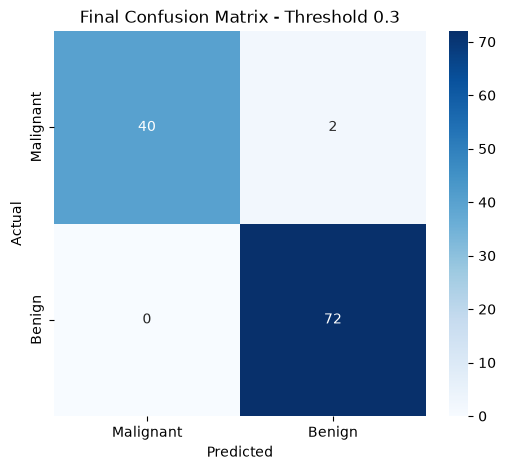

In [21]:
final_cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Malignant",
        "Benign"
    ],
    yticklabels=[
        "Malignant",
        "Benign"
    ]
)

plt.title(
    f"Final Confusion Matrix - Threshold {selected_threshold}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Observation

1. The Logistic Regression classifier was successfully trained on the binary classification dataset.
2. Predicted probabilities for the positive class were obtained using `predict_proba()`.
3. Different classification thresholds ranging from 0.1 to 0.9 were applied.
4. Changing the threshold significantly affected precision, recall, false positives, false negatives, and the confusion matrix.
5. Lower thresholds generally produced more positive predictions and tended to increase recall.
6. Higher thresholds generally produced fewer positive predictions and tended to increase precision.
7. ROC and Precision-Recall curves were successfully generated.
8. The class distribution was examined to determine whether the dataset was balanced or imbalanced.
9. The threshold can be selected according to the relative costs of false positives and false negatives.

## Result

The Logistic Regression classifier was successfully implemented for binary classification.

Predicted probabilities were obtained using `predict_proba()`. The effect of different classification thresholds on precision, recall, false positives, false negatives, and confusion matrices was analyzed.

The ROC and Precision-Recall curves were successfully plotted.

It was observed that changing the classification threshold creates a trade-off between precision and recall. Therefore, the threshold should be selected according to the requirements and real-world costs of the application rather than automatically using 0.5.

## Conclusion

Logistic Regression can be effectively used for binary classification by converting predicted probabilities into class labels using a classification threshold.

Lower thresholds generally favor recall, while higher thresholds generally favor precision. The ROC and Precision-Recall curves provide useful ways to evaluate model performance across different thresholds.

The experiment demonstrates that a threshold of 0.5 is not always the best choice. In real-world applications such as fraud detection, the threshold should be selected based on the relative costs of false positives and false negatives.